<a href="https://colab.research.google.com/github/mohamedshehada/Car-Insurance-Claim-Prediction/blob/main/Car_Insurance_Claim_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')


print('Libraries imported successfully!')

Libraries imported successfully!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:

def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8, 4),
                           normalize='true', cmap='Blues', colorbar=False):

   ## Prints classification report and displays two confusion matrices:
    #- Left: raw counts
    #- Right: normalized

    #Parameters:
        #y_true: truth labels
        #y_pred: Predicted labels)
    report = classification_report(y_true, y_pred)
    header = '-' * 70
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)

    fig, axes = plt.subplots(ncols=2, figsize=figsize)

    # Left matrix: raw counts
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        normalize=None, cmap='gist_gray',
        colorbar=colorbar, ax=axes[0]
    )
    axes[0].set_title('Raw Counts')

    # Right matrix: normalized
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        normalize=normalize, cmap=cmap,
        colorbar=colorbar, ax=axes[1]
    )
    axes[1].set_title('Normalized Confusion Matrix')

    fig.tight_layout()
    plt.show()

    if output_dict:
        return classification_report(y_true, y_pred, output_dict=True)


def evaluate_classification(model, X_train, y_train, X_test, y_test,
                            figsize=(6, 4), normalize='true', output_dict=False,
                            cmap_train='Blues', cmap_test='Reds', colorbar=False):

    # Evaluate on training data
    y_train_pred = model.predict(X_train)
    results_train = classification_metrics(
        y_train, y_train_pred,
        output_dict=True, figsize=figsize,
        colorbar=colorbar, cmap=cmap_train,
        label='Training Data'
    )
    print()

    # Evaluate on test data
    y_test_pred = model.predict(X_test)
    results_test = classification_metrics(
        y_test, y_test_pred,
        output_dict=True, figsize=figsize,
        colorbar=colorbar, cmap=cmap_test,
        label='Test Data'
    )

    if output_dict:
        return {'train': results_train, 'test': results_test}

## 2. Load and Inspect the Data

In [4]:
file_path = "/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/05-IntermediateML/Week18/Data/Car_Insurance_Claim.csv"
df = pd.read_csv(file_path)

print('Shape:', df.shape)
df.head()

Shape: (10000, 19)


,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,16-25,male,majority,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,26-39,male,majority,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [5]:
print('Data Types and Missing Values')
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'missing_count': df.isnull().sum(),
    'missing_%': (df.isnull().sum() / len(df) * 100).round(2)})
info_df

Data Types and Missing Values


,dtype,missing_count,missing_%
ID,int64,0,0.00
AGE,object,0,0.00
GENDER,object,0,0.00
RACE,object,0,0.00
DRIVING_EXPERIENCE,object,0,0.00
EDUCATION,object,0,0.00
INCOME,object,0,0.00
CREDIT_SCORE,float64,982,9.82
VEHICLE_OWNERSHIP,float64,0,0.00
VEHICLE_YEAR,object,0,0.00


In [6]:
print('Target Distribution')
print(df['OUTCOME'].value_counts())
print('\nClass balance (%):')
print((df['OUTCOME'].value_counts(normalize=True) * 100))

Target Distribution
OUTCOME
0.0    6867
1.0    3133
Name: count, dtype: int64

Class balance (%):
OUTCOME
0.0    68.67
1.0    31.33
Name: proportion, dtype: float64


In [7]:
print('Numeric Summary Statistics')
df.describe().round(2)

Numeric Summary Statistics


,ID,CREDIT_SCORE,VEHICLE_OWNERSHIP,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
count,10000.00,9018.00,10000.00,10000.0,10000.00,10000.00,9043.00,10000.00,10000.00,10000.00,10000.00
mean,500521.91,0.52,0.70,0.5,0.69,19864.55,11697.00,1.48,0.24,1.06,0.31
std,290030.77,0.14,0.46,0.5,0.46,18915.61,2818.43,2.24,0.55,1.65,0.46
min,101.00,0.05,0.00,0.0,0.00,10238.00,2000.00,0.00,0.00,0.00,0.00
25%,249638.50,0.42,0.00,0.0,0.00,10238.00,10000.00,0.00,0.00,0.00,0.00
50%,501777.00,0.53,1.00,0.0,1.00,10238.00,12000.00,0.00,0.00,0.00,0.00
75%,753974.50,0.62,1.00,1.0,1.00,32765.00,14000.00,2.00,0.00,2.00,1.00
max,999976.00,0.96,1.00,1.0,1.00,92101.00,22000.00,22.00,6.00,15.00,1.00


## 3. Data Cleaning

In [8]:
# Drop ID
df = df.drop(columns=['ID'])

# Convert OUTCOME to integer
df['OUTCOME'] = df['OUTCOME'].astype(int)

# VEHICLE_OWNERSHIP, MARRIED, CHILDREN are already 0/1 floats — convert to int
for col in ['VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN']:
    df[col] = df[col].astype(int)

print('Shape after dropping ID and POSTAL_CODE:', df.shape)
print('\nRemaining missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape after dropping ID and POSTAL_CODE: (10000, 18)

Remaining missing values:
CREDIT_SCORE      982
ANNUAL_MILEAGE    957
dtype: int64


In [9]:
# Verify unique values for all categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f'{col}: {df[col].unique().tolist()}')

AGE: ['65+', '16-25', '26-39', '40-64']
GENDER: ['female', 'male']
RACE: ['majority', 'minority']
DRIVING_EXPERIENCE: ['0-9y', '10-19y', '20-29y', '30y+']
EDUCATION: ['high school', 'none', 'university']
INCOME: ['upper class', 'poverty', 'working class', 'middle class']
VEHICLE_YEAR: ['after 2015', 'before 2015']
VEHICLE_TYPE: ['sedan', 'sports car']


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   AGE                  10000 non-null  object 
 1   GENDER               10000 non-null  object 
 2   RACE                 10000 non-null  object 
 3   DRIVING_EXPERIENCE   10000 non-null  object 
 4   EDUCATION            10000 non-null  object 
 5   INCOME               10000 non-null  object 
 6   CREDIT_SCORE         9018 non-null   float64
 7   VEHICLE_OWNERSHIP    10000 non-null  int64  
 8   VEHICLE_YEAR         10000 non-null  object 
 9   MARRIED              10000 non-null  int64  
 10  CHILDREN             10000 non-null  int64  
 11  POSTAL_CODE          10000 non-null  int64  
 12  ANNUAL_MILEAGE       9043 non-null   float64
 13  VEHICLE_TYPE         10000 non-null  object 
 14  SPEEDING_VIOLATIONS  10000 non-null  int64  
 15  DUIS                 10000 non-null  

## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Distribution

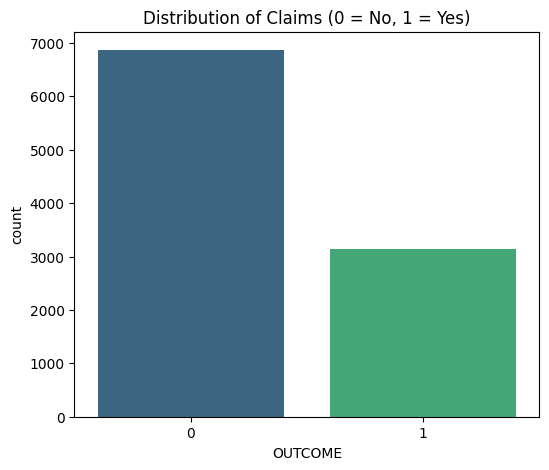

In [11]:
# Target Variable distribution
plt.figure(figsize=(6, 5))
sns.countplot(x='OUTCOME', data=df, palette='viridis')
plt.title('Distribution of Claims (0 = No, 1 = Yes)')
plt.savefig("Distribution of Claims", dpi=300, bbox_inches='tight')
plt.show()


### 4.2 Vehicle Type vs Claim

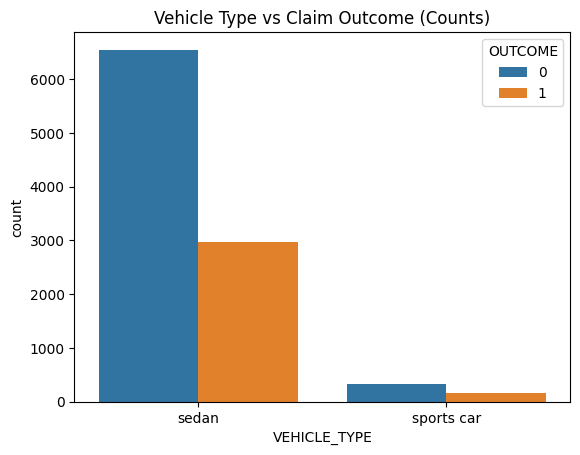

In [12]:
# 2. VehicleType vs Claim
sns.countplot(data=df, x="VEHICLE_TYPE", hue="OUTCOME")
plt.title("Vehicle Type vs Claim Outcome (Counts)")
plt.savefig("vehicle_type_vs_claim.png", dpi=300, bbox_inches='tight')
plt.show()

### 4.3 Age Group vs Claim Rate

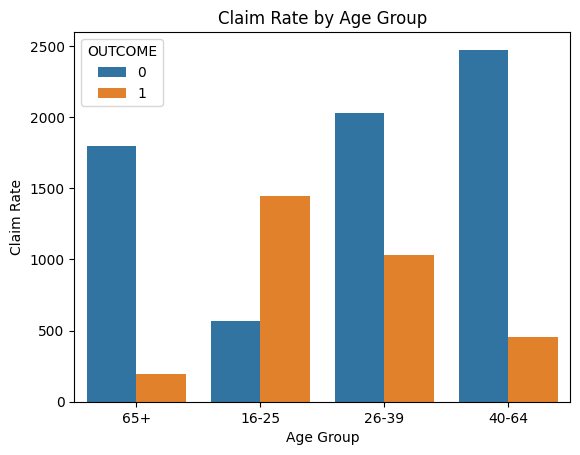

In [13]:
# Claim rate by Age group
sns.countplot(data=df, x="AGE", hue="OUTCOME")
plt.title("Claim Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Claim Rate")
plt.savefig("claim_rate_by_age.png", dpi=300, bbox_inches='tight')
plt.show()



### 4.4 Correlation Heatmap (Numeric Features)

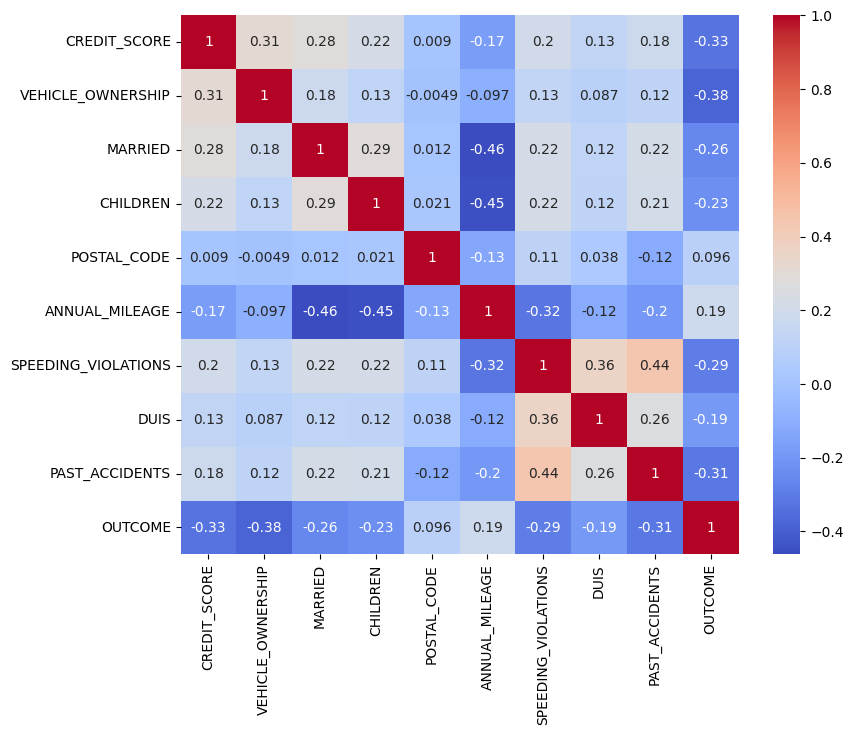

In [14]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

## 5. Preprocessing and Modeling

### 5.1 Define Features and Target — Train/Test Split

In [15]:
X = df.drop(columns=['OUTCOME'])
y = df['OUTCOME']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Training set:', X_train.shape)
print('Test set    :', X_test.shape)
print('\nTarget balance in training set:')
print(y_train.value_counts(normalize=True).round(3))

Training set: (8000, 17)
Test set    : (2000, 17)

Target balance in training set:
OUTCOME
0    0.687
1    0.313
Name: proportion, dtype: float64


### 5.2 Define Column Types

In [16]:
# Numeric
numeric_features = ['CREDIT_SCORE', 'ANNUAL_MILEAGE', 'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS', 'POSTAL_CODE']

# Binary — already 0/1, no encoding needed
binary_features = ['VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN']

# Ordinal — have a meaningful order
ordinal_features = ['AGE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME']
ordinal_categories = [
    ['16-25', '26-39', '40-64', '65+'],                            # AGE
    ['0-9y', '10-19y', '20-29y', '30y+'],                         # DRIVING_EXPERIENCE
    ['none', 'high school', 'university'],                         # EDUCATION
    ['poverty', 'working class', 'middle class', 'upper class'],   # INCOME
]

# Nominal — no meaningful order
nominal_features = ['GENDER', 'RACE', 'VEHICLE_YEAR', 'VEHICLE_TYPE']

print('Numeric  :', numeric_features)
print('Binary   :', binary_features)
print('Ordinal  :', ordinal_features)
print('Nominal  :', nominal_features)

Numeric  : ['CREDIT_SCORE', 'ANNUAL_MILEAGE', 'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS', 'POSTAL_CODE']
Binary   : ['VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN']
Ordinal  : ['AGE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME']
Nominal  : ['GENDER', 'RACE', 'VEHICLE_YEAR', 'VEHICLE_TYPE']


### 5.3 Build ColumnTransformer + Pipeline

In [17]:
# Numeric: impute missing values with median, then scale
numeric_transformer = make_pipeline(SimpleImputer(strategy='median'),StandardScaler())

# Binary: impute only (no scaling needed for 0/1 columns)
binary_transformer = make_pipeline(SimpleImputer(strategy='most_frequent'))

# Ordinal: encode according to natural order
ordinal_transformer = make_pipeline(OrdinalEncoder(categories=ordinal_categories,handle_unknown='use_encoded_value',unknown_value=-1))

# Nominal: one-hot encode
nominal_transformer = make_pipeline(OneHotEncoder(handle_unknown='ignore', sparse_output=False))

preprocessor = ColumnTransformer([
    ('num', numeric_transformer,  numeric_features),
    ('bin', binary_transformer,   binary_features),
    ('ord', ordinal_transformer,  ordinal_features),
    ('nom', nominal_transformer,  nominal_features)
])
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['CREDIT_SCORE', 'ANNUAL_MILEAGE',
                                  'SPEEDING_VIOLATIONS', 'DUIS',
                                  'PAST_ACCIDENTS', 'POSTAL_CODE']),
                                ('bin',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['VEHICLE_OWNERSHIP', 'MARRIE...
                                                                             ['none',
                                                                              'high '
                                                                              'school',
                                                                              'university'],
                                                                             ['poverty',
                                                                              'working '
                                                                              'class',
                                                                              'middle '
                                                                              'class',
                                                                              'upper '
                                                                              'class']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['AGE', 'DRIVING_EXPERIENCE', 'EDUCATION',
                                  'INCOME']),
                                ('nom',
                                 Pipeline(steps=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['GENDER', 'RACE', 'VEHICLE_YEAR',
                                  'VEHICLE_TYPE'])])

In [18]:
# Random Forest: ensemble of decision trees that reduces overfitting
# Each tree is trained on a random subset of rows and features
rf_pipe = make_pipeline(preprocessor,RandomForestClassifier(random_state=42))
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['CREDIT_SCORE',
                                                   'ANNUAL_MILEAGE',
                                                   'SPEEDING_VIOLATIONS',
                                                   'DUIS', 'PAST_ACCIDENTS',
                                                   'POSTAL_CODE']),
                                                 ('bin',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequ...
                                                                                               'class',
                                                                                               'upper '
                                                                                               'class']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['AGE', 'DRIVING_EXPERIENCE',
                                                   'EDUCATION', 'INCOME']),
                                                 ('nom',
                                                  Pipeline(steps=[('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['GENDER', 'RACE',
                                                   'VEHICLE_YEAR',
                                                   'VEHICLE_TYPE'])])),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

### 5.4 Fit and Evaluate the Default Model

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5494
           1       1.00      1.00      1.00      2506

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



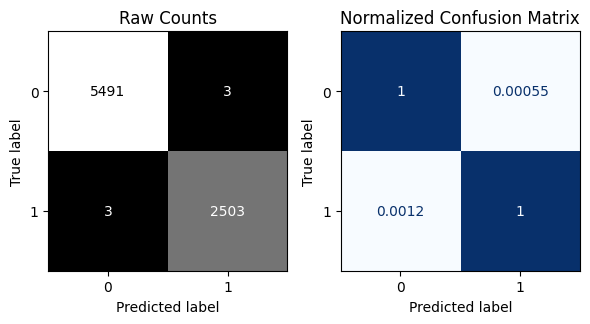


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1373
           1       0.72      0.70      0.71       627

    accuracy                           0.82      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.82      0.82      0.82      2000



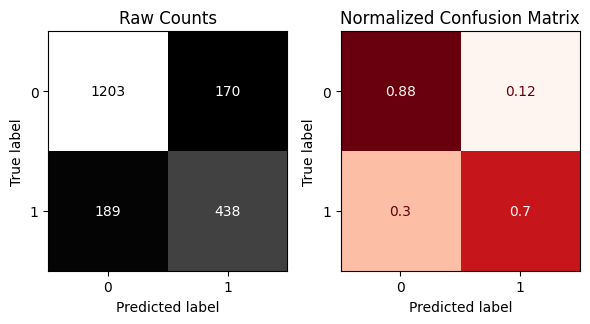

In [19]:
evaluate_classification(rf_pipe, X_train, y_train, X_test, y_test)

## 6. Permutation Importance — Top 10 Features

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

def get_importances(model, feature_names=None, name='Feature Importance',
                    sort=False, ascending=True):

    if hasattr(model, "named_steps"):
        estimator = list(model.named_steps.values())[-1]
        preprocessor = model.named_steps.get('preprocessor', None) \
                       or model.named_steps.get('columntransformer', None)
    else:
        estimator = model
        preprocessor = None

    if feature_names is None:
        if preprocessor is not None:
            feature_names = preprocessor.get_feature_names_out()
        else:
            feature_names = [f"feature_{i}"
                             for i in range(len(estimator.feature_importances_))]

    feature_names = [name.split("__")[-1] for name in feature_names]

    importances = pd.Series(estimator.feature_importances_,
                             index=feature_names,
                             name=name)

    if sort:
        importances = importances.sort_values(ascending=ascending)

    return importances


def plot_importance(importances, top_n=None, figsize=(8, 6)):

    if top_n is None:
        plot_vals = importances.sort_values()
        title = "All Features - Ranked by Importance"
    else:
        plot_vals = importances.sort_values().tail(top_n)
        title = f"Top {top_n} Most Important Features"

    ax = plot_vals.plot(kind='barh', figsize=figsize)
    ax.set_xlabel('Importance')
    ax.set_ylabel('Feature Names')
    ax.set_title(title)

    return ax

6.1 Extracting Top 10 Features
Objective:  
To display the most important features ranked by their importance scores from the Random Forest model.
This step prints the top 10 features with their corresponding importance values, providing a clear view of which variables have the strongest impact on predictions.

In [21]:
importances = get_importances(rf_pipe, sort=True, ascending=False)
top10 = importances.head(10)
print("Top 10 Features:\n", top10)


Top 10 Features:
 CREDIT_SCORE               0.169033
DRIVING_EXPERIENCE         0.124515
ANNUAL_MILEAGE             0.096590
AGE                        0.081158
VEHICLE_OWNERSHIP          0.079635
SPEEDING_VIOLATIONS        0.069662
INCOME                     0.060971
POSTAL_CODE                0.051803
PAST_ACCIDENTS             0.050474
VEHICLE_YEAR_after 2015    0.037449
Name: Feature Importance, dtype: float64


6.2 Visualizing Top 10 Features
Objective:  
To create a clear visualization of the top 10 most important features identified by the Random Forest model.
This plot highlights the relative importance of each feature, making it easier to interpret and communicate which variables have the strongest influence on claim predictions.

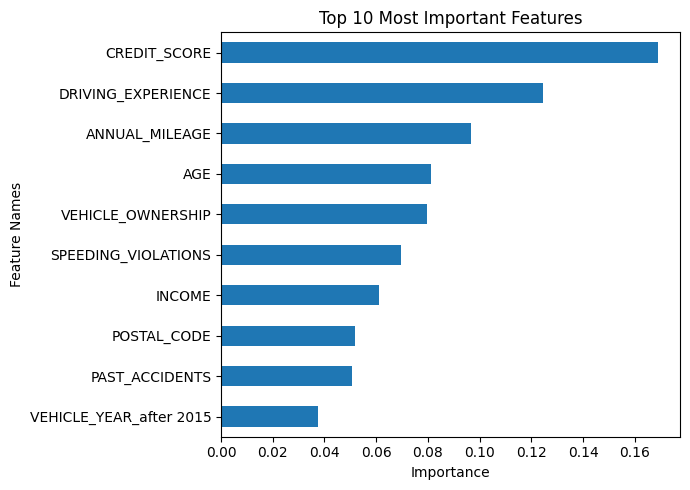

In [22]:
ax = plot_importance(importances, top_n=10, figsize=(7,5))

fig = ax.get_figure()
fig.tight_layout()
fig.savefig("top10_features.png", dpi=300)
plt.show()

### Observations: Do These Features Make Sense for the Business Case?

1. Credit Score – Lower credit scores are associated with higher claim risk, reflecting financial responsibility.

2. Driving Experience – Less experienced drivers tend to have more accidents and higher claim rates.

3. Annual Mileage – More miles driven increases exposure to risk and likelihood of claims.

4. Vehicle Ownership – Owners may be more cautious than non‑owners.

5. Age – Younger drivers often show higher risk, while very old drivers may also have elevated claim rates.

6. Income – Income can influence vehicle type and driving behavior, which in turn affects claim probability.

7. Speeding Violations - More violations strongly correlate with risky driving and higher claims.

8. Past Accidents – A history of accidents is a strong predictor of future claims.

9. Education – Education may correlate with risk awareness and driving behavior, though the relationship is indirect.

10. Vehicle Year (before 2015) – Logical. Older vehicles are less safe and more prone to breakdowns, increasing claim probability.

## 7. Explanatory Visualizations for Stakeholders

### 7.1 Feature 1: Credit Score vs. Claim Outcome

**Insight:**   
Customers with higher credit scores are less likely to file insurance claims. The bar chart shows that claimants (Outcome = 1) have lower average credit scores compared to non‑claimants (Outcome = 0). This highlights credit score as a useful predictor of claim risk.

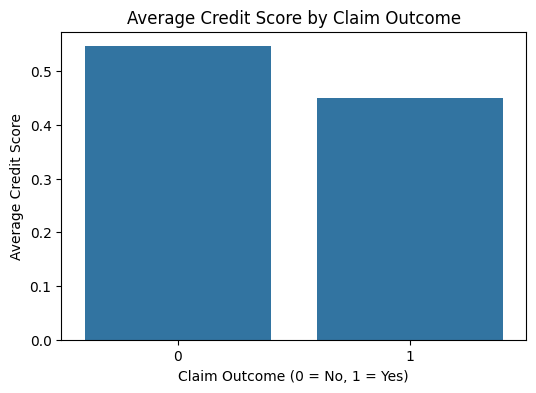

In [23]:
plt.figure(figsize=(6,4))
sns.barplot(x='OUTCOME', y='CREDIT_SCORE', data=df, ci=None)
plt.title("Average Credit Score by Claim Outcome")
plt.xlabel("Claim Outcome (0 = No, 1 = Yes)")
plt.ylabel("Average Credit Score")
fig.savefig("Average Credit_Score by Claim Outcome.png", dpi=300)
plt.show()


### 7.2 Feature 2: Feature 1: Driving Experience vs Claim Rate

**Insight:** Drivers with less experience (0–9 years) file insurance claims at a much higher rate compared to experienced drivers. The bar chart shows a clear downward trend: as driving experience increases, claim rates drop. This confirms that driving experience is a strong predictor of insurance risk.

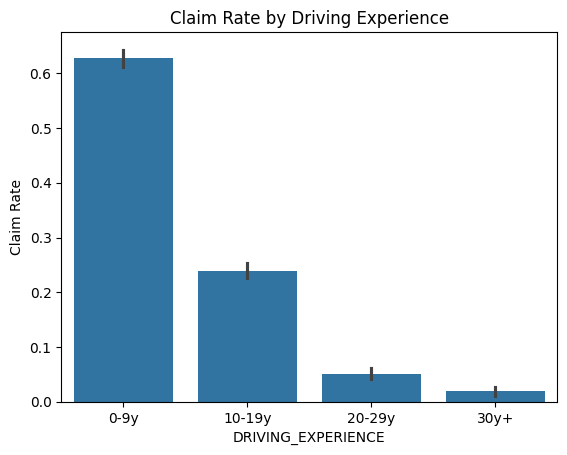

In [24]:
sns.barplot(x='DRIVING_EXPERIENCE',y='OUTCOME',data=df,)
plt.title('Claim Rate by Driving Experience')
plt.ylabel('Claim Rate')
fig.savefig("Claim Rate by Driving Experience.png", dpi=300)
plt.show()


## 8. Summary

| Metric | Value |
|---|---|
| Model | Random Forest Classifier (default) |
| Train Accuracy | 1.00 (overfitting — next step: GridSearchCV tuning) |
| **Test Accuracy** | **0.81** |
| Top Feature #1 | `DRIVING_EXPERIENCE` (importance: 0.187311) |
| Top Feature #2 | `Credit Score` (importance: 0.128586) |

**Key Takeaways:**
- Driving experience and credit score are the strongest predictors of insurance claim risk, supported by explanatory visualizations.

- The default Random Forest shows overfitting (perfect train accuracy vs ~81% test accuracy). Next step: GridSearchCV tuning to improve generalization.

- Class imbalance (≈69/31) was handled using stratified train/test split to ensure representative distribution.

- Missing values in Credit Score and Annual Mileage were imputed inside the pipeline to prevent data leakage